In [1]:
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install seaborn
! pip install scikit-learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

sns.set_style('whitegrid')

### 1. LOADING DATASET

In [7]:
df = pd.read_csv(r"C:\Users\Saran\OneDrive\Desktop\india_house_price_prediction.csv")

print(f'Rows : {len(df):,}  |  Columns : {df.shape[1]}')
print(f'Cities : {list(df["city"].unique())}')

df[['city','property_type','bhk','total_sqft','price_in_lakhs']].head(5)

Rows : 2,000  |  Columns : 39
Cities : ['Delhi', 'Ahmedabad', 'Mumbai', 'Jaipur', 'Pune', 'Hyderabad', 'Bengaluru', 'Kolkata', 'Chennai', 'Coimbatore']


,city,property_type,bhk,total_sqft,price_in_lakhs
0,Delhi,Villa,5,3806,287.89
1,Ahmedabad,Apartment,2,1950,57.01
2,Mumbai,Builder Floor,3,1692,117.30
3,Jaipur,Penthouse,4,1894,90.91
4,Pune,Builder Floor,1,1380,59.52


### 2. DATA SUMMARY


In [8]:
print(f'Avg Size  : {df["total_sqft"].mean():,.0f} sqft')
print(f'Avg Price : ₹{df["price_in_lakhs"].mean():.1f} Lakhs')
print(f'Min Price : ₹{df["price_in_lakhs"].min():.1f}L  |  Max : ₹{df["price_in_lakhs"].max():.1f}L')
print(f'Correlation (Size ↔ Price) : {df["total_sqft"].corr(df["price_in_lakhs"]):.3f}')
print('  → Closer to 1.0 means size is a strong predictor of price')

Avg Size  : 1,959 sqft
Avg Price : ₹100.3 Lakhs
Min Price : ₹9.1L  |  Max : ₹697.6L
Correlation (Size ↔ Price) : 0.843
  → Closer to 1.0 means size is a strong predictor of price


### 3. VISULAIZING THE DATA

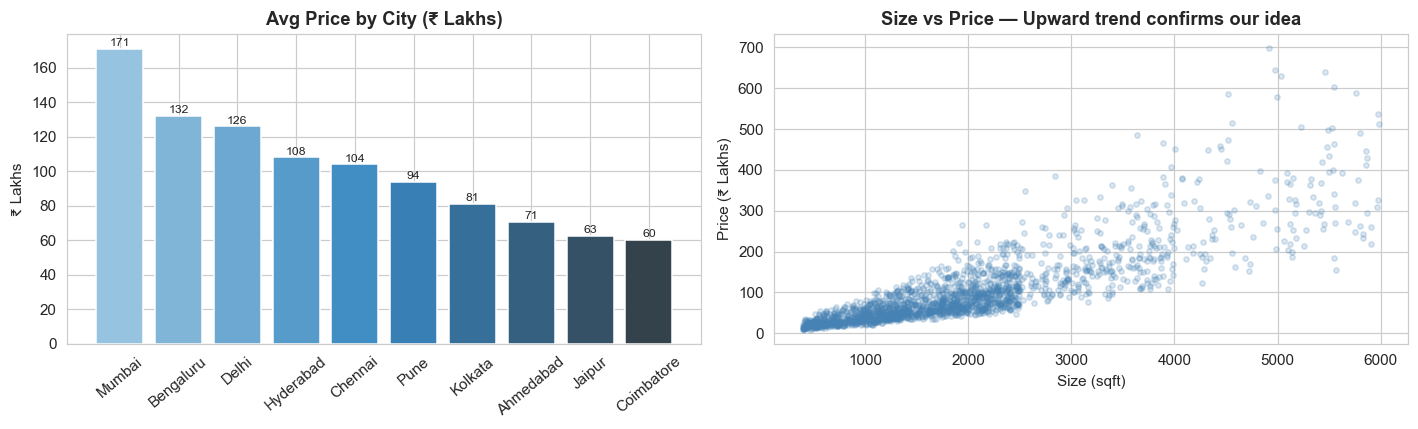

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

city_avg = df.groupby('city')['price_in_lakhs'].mean().sort_values(ascending=False)
bars = axes[0].bar(city_avg.index, city_avg.values,
                   color=sns.color_palette('Blues_d', len(city_avg)), edgecolor='white')
for bar, val in zip(bars, city_avg.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                 f'{val:.0f}', ha='center', fontsize=8)
axes[0].set_title('Avg Price by City (₹ Lakhs)', fontweight='bold')
axes[0].set_ylabel('₹ Lakhs')
axes[0].tick_params(axis='x', rotation=40)

axes[1].scatter(df['total_sqft'], df['price_in_lakhs'],
                alpha=0.2, color='steelblue', s=12)
axes[1].set_title('Size vs Price — Upward trend confirms our idea', fontweight='bold')
axes[1].set_xlabel('Size (sqft)')
axes[1].set_ylabel('Price (₹ Lakhs)')

plt.tight_layout()
plt.show()

### 4. TRAINING THE MODEL

In [10]:
X = df[['total_sqft']]
y = df['price_in_lakhs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

s = model.coef_[0]
c = model.intercept_

print(f'Train : {len(X_train):,}  |  Test : {len(X_test):,}')
print(f'Formula → Price = {s:.5f} × Size + ({c:.2f})')
print(f'Every extra 100 sqft adds ≈ ₹{s*100:.2f} Lakhs')

Train : 1,600  |  Test : 400
Formula → Price = 0.06496 × Size + (-26.92)
Every extra 100 sqft adds ≈ ₹6.50 Lakhs


### 5. MODEL ACCURACY CHECK

In [11]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = np.mean(np.abs(y_test.values - y_pred))

print(f'R² Score : {r2:.4f}  →  {r2*100:.1f}% of price variation explained by size')
print(f'MAE      : ₹{mae:.2f} Lakhs  (average prediction error)')
print(f'RMSE     : ₹{rmse:.2f} Lakhs')
print()
sample = pd.DataFrame({
    'Size(sqft)':   X_test['total_sqft'].values[:8],
    'Actual(₹L)':  y_test.values[:8].round(1),
    'Predicted(₹L)': y_pred[:8].round(1),
    'Error(₹L)':  (y_test.values[:8] - y_pred[:8]).round(1)
})
print(sample.to_string(index=False))

R² Score : 0.6919  →  69.2% of price variation explained by size
MAE      : ₹33.02 Lakhs  (average prediction error)
RMSE     : ₹49.59 Lakhs

 Size(sqft)  Actual(₹L)  Predicted(₹L)  Error(₹L)
       1293        79.4           57.1       22.3
       2022        98.0          104.4       -6.4
       1824        52.0           91.6      -39.6
       2201       166.3          116.1       50.2
       1615        55.7           78.0      -22.3
       1447       105.0           67.1       37.9
       1831        90.7           92.0       -1.3
       1311        34.6           58.2      -23.6


### 6.VISULAIZING THE MODEL RESULTS

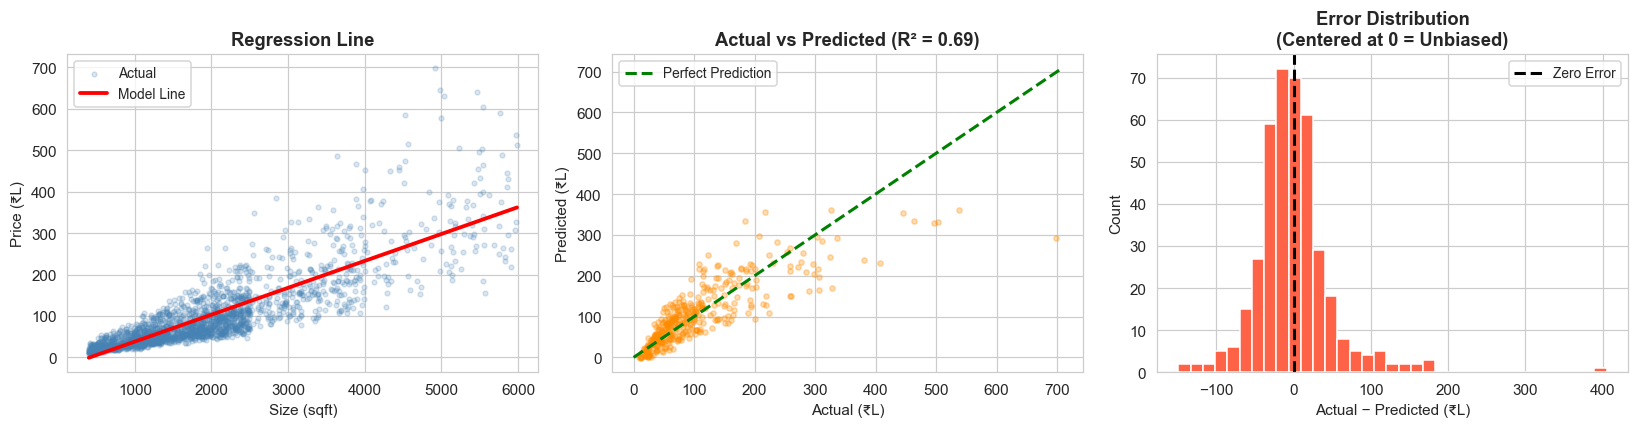

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['total_sqft'],df['price_in_lakhs'],alpha=0.2,color='steelblue',s=10,label='Actual')

x_line = np.linspace(df['total_sqft'].min(),df['total_sqft'].max(),200).reshape(-1, 1)

x_line_df = pd.DataFrame(x_line, columns=['total_sqft'])
y_line_pred = model.predict(x_line_df)

axes[0].plot(x_line,y_line_pred,color='red',lw=2.5,label='Model Line')

axes[0].set_title('Regression Line', fontweight='bold')
axes[0].set_xlabel('Size (sqft)')
axes[0].set_ylabel('Price (₹L)')
axes[0].legend(fontsize=9)

axes[1].scatter(y_test,y_pred,alpha=0.3,color='darkorange',s=12)

lim = [0, max(y_test.max(), y_pred.max()) + 10]

axes[1].plot(lim,lim,'g--',lw=2,label='Perfect Prediction')
             
axes[1].set_title(f'Actual vs Predicted (R² = {r2:.2f})',fontweight='bold')

axes[1].set_xlabel('Actual (₹L)')
axes[1].set_ylabel('Predicted (₹L)')
axes[1].legend(fontsize=9)

errors = y_test.values - y_pred

axes[2].hist(errors,bins=35,color='tomato',edgecolor='white')

axes[2].axvline(0,color='black',lw=2,ls='--',label='Zero Error')

axes[2].set_title('Error Distribution\n(Centered at 0 = Unbiased)',fontweight='bold')

axes[2].set_xlabel('Actual − Predicted (₹L)')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [18]:

print(f"{'Size':>12}  |  {'Price (₹L)':>12}  |  {'Crores':>10}")
print('-' * 42)

for size in [800, 1000, 1200, 1500, 2000, 2500, 3000]:
    
    input_df = pd.DataFrame([[size]],columns=['total_sqft'])

    p = model.predict(input_df)[0]

    print(f"{size:>6} sqft  |  ₹{p:>8.1f}L    |  ₹{p/100:.2f} Cr")

print()

my_size = 1500
my_house_df = pd.DataFrame([[my_size]],columns=['total_sqft'])
my_price = model.predict(my_house_df)[0]

print(f"YOUR HOUSE → {my_size} sqft")
print(f"Predicted  → ₹{my_price:.2f} Lakhs  (₹{my_price/100:.2f} Crores)")



        Size  |    Price (₹L)  |      Crores
------------------------------------------
   800 sqft  |  ₹    25.1L    |  ₹0.25 Cr
  1000 sqft  |  ₹    38.0L    |  ₹0.38 Cr
  1200 sqft  |  ₹    51.0L    |  ₹0.51 Cr
  1500 sqft  |  ₹    70.5L    |  ₹0.71 Cr
  2000 sqft  |  ₹   103.0L    |  ₹1.03 Cr
  2500 sqft  |  ₹   135.5L    |  ₹1.35 Cr
  3000 sqft  |  ₹   168.0L    |  ₹1.68 Cr

YOUR HOUSE → 1500 sqft
Predicted  → ₹70.52 Lakhs  (₹0.71 Crores)
